In [13]:
# from dotenv import load_dotenv
# load_dotenv()

In [14]:
# import os
# os.environ['LD_LIBRARY_PATH'] = '/home/baris/miniconda3/envs/verifiers/lib/python3.11/site-packages/nvidia/nvjitlink/lib'

In [15]:
import json
import textwrap
import pandas as pd
from ipywidgets import widgets
from IPython.display import display
from ipywidgets import HBox
import matplotlib.pyplot as plt
from tabulate import tabulate


In [16]:
filepath = "../tmp/evals/Llama-3.1-8B-Instruct-ragent-1/predictions.jsonl"
df = pd.read_json(filepath, lines=True)
df.head()

,id,answer,prompt,docs,answers,supporting_titles,trajectory
0,2hop__734582_71302,Vito Corleone,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[vito corleone, Vito Corleone, Vito Andolini C...","[The Good Shepherd (film), The Godfather Part II]",[{'content': 'Answer the question based on the...
1,2hop__700093_455653,Rohana Wijeweera,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[Rohana Wijeweera, rohana wijeweera]","[Rohana Wijeweera, Dimuthu Bandara Abayakoon]",[{'content': 'Answer the question based on the...
2,2hop__203955_25719,406,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...",[406],"[Rössen culture, Galicia (Spain)]",[{'content': 'Answer the question based on the...
3,2hop__83800_747874,Jamie Murray,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[Jamie Murray, jamie murray]","[2011 Valencia Open 500 – Doubles, 2016 Wimble...",[{'content': 'Answer the question based on the...
4,2hop__21104_16334,modern-day Italians,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[modern-day Italians, modern-day italians]","[Jews, Ashkenazi Jews]",[{'content': 'Answer the question based on the...


In [17]:
from verifiers.rubrics.musique import extract_all_retrieved_titles, get_last_answer

df["retrieved_titles"] = df["trajectory"].apply(lambda x: list(extract_all_retrieved_titles(x)))
df["missing_titles"] = df.apply(lambda row: list(set(row["supporting_titles"]) - set(row["retrieved_titles"])), axis=1)
df['n_hops'] = df['supporting_titles'].apply(len)
df['predicted_answer'] = df['trajectory'].apply(get_last_answer)

In [18]:
from verifiers.rubrics.musique import musique_f1_reward_func, musique_em_reward_func, musique_supporting_f1_reward_func, musique_supporting_recall_reward_func

em_rewards = musique_em_reward_func(df['trajectory'].values, df['answers'].values)
df['reward.em'] = em_rewards

f1_rewards = musique_f1_reward_func(df['trajectory'].values, df['answers'].values)
df['reward.f1'] = f1_rewards

supporting_f1_rewards = musique_supporting_f1_reward_func(df['trajectory'].values, df['supporting_titles'].values)
df['reward.supporting_f1'] = supporting_f1_rewards

supporting_recall_rewards = musique_supporting_recall_reward_func(df['trajectory'].values, df['supporting_titles'].values)
df['reward.supporting_recall'] = supporting_recall_rewards

In [19]:
df.head()

,id,answer,prompt,docs,answers,supporting_titles,trajectory,retrieved_titles,missing_titles,n_hops,predicted_answer,reward.em,reward.f1,reward.supporting_f1,reward.supporting_recall
0,2hop__734582_71302,Vito Corleone,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[vito corleone, Vito Corleone, Vito Andolini C...","[The Good Shepherd (film), The Godfather Part II]",[{'content': 'Answer the question based on the...,"[The Good Shepherd (film), The Godfather Part II]",[],2,Robert De Niro,0,0.0,1.0,1.0
1,2hop__700093_455653,Rohana Wijeweera,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[Rohana Wijeweera, rohana wijeweera]","[Rohana Wijeweera, Dimuthu Bandara Abayakoon]",[{'content': 'Answer the question based on the...,"[Dimuthu Bandara Abayakoon, Rohana Wijeweera]",[],2,Rohana Wijeweera,1,1.0,1.0,1.0
2,2hop__203955_25719,406,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...",[406],"[Rössen culture, Galicia (Spain)]",[{'content': 'Answer the question based on the...,"[Rössen culture, Tamástslikt Cultural Institute]",[Galicia (Spain)],2,None,0,0.0,0.5,0.5
3,2hop__83800_747874,Jamie Murray,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[Jamie Murray, jamie murray]","[2011 Valencia Open 500 – Doubles, 2016 Wimble...",[{'content': 'Answer the question based on the...,"[2016 Wimbledon Championships, 2011 Valencia O...",[],2,Jamie Murray,1,1.0,1.0,1.0
4,2hop__21104_16334,modern-day Italians,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[modern-day Italians, modern-day italians]","[Jews, Ashkenazi Jews]",[{'content': 'Answer the question based on the...,"[Ashkenazi Jews, Jews]",[],2,Lebanese people,0,0.0,1.0,1.0


In [ ]:
df[['reward.em', 'reward.f1', 'reward.supporting_f1', 'reward.supporting_recall']].describe()

,reward.em,reward.f1,reward.supporting_f1,reward.supporting_recall
count,300.000000,300.000000,300.000000,300.000000
mean,0.400000,0.483346,0.791254,0.747500
std,0.490716,0.467998,0.223189,0.244349
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.666667,0.500000
50%,0.000000,0.400000,0.857143,0.750000
75%,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


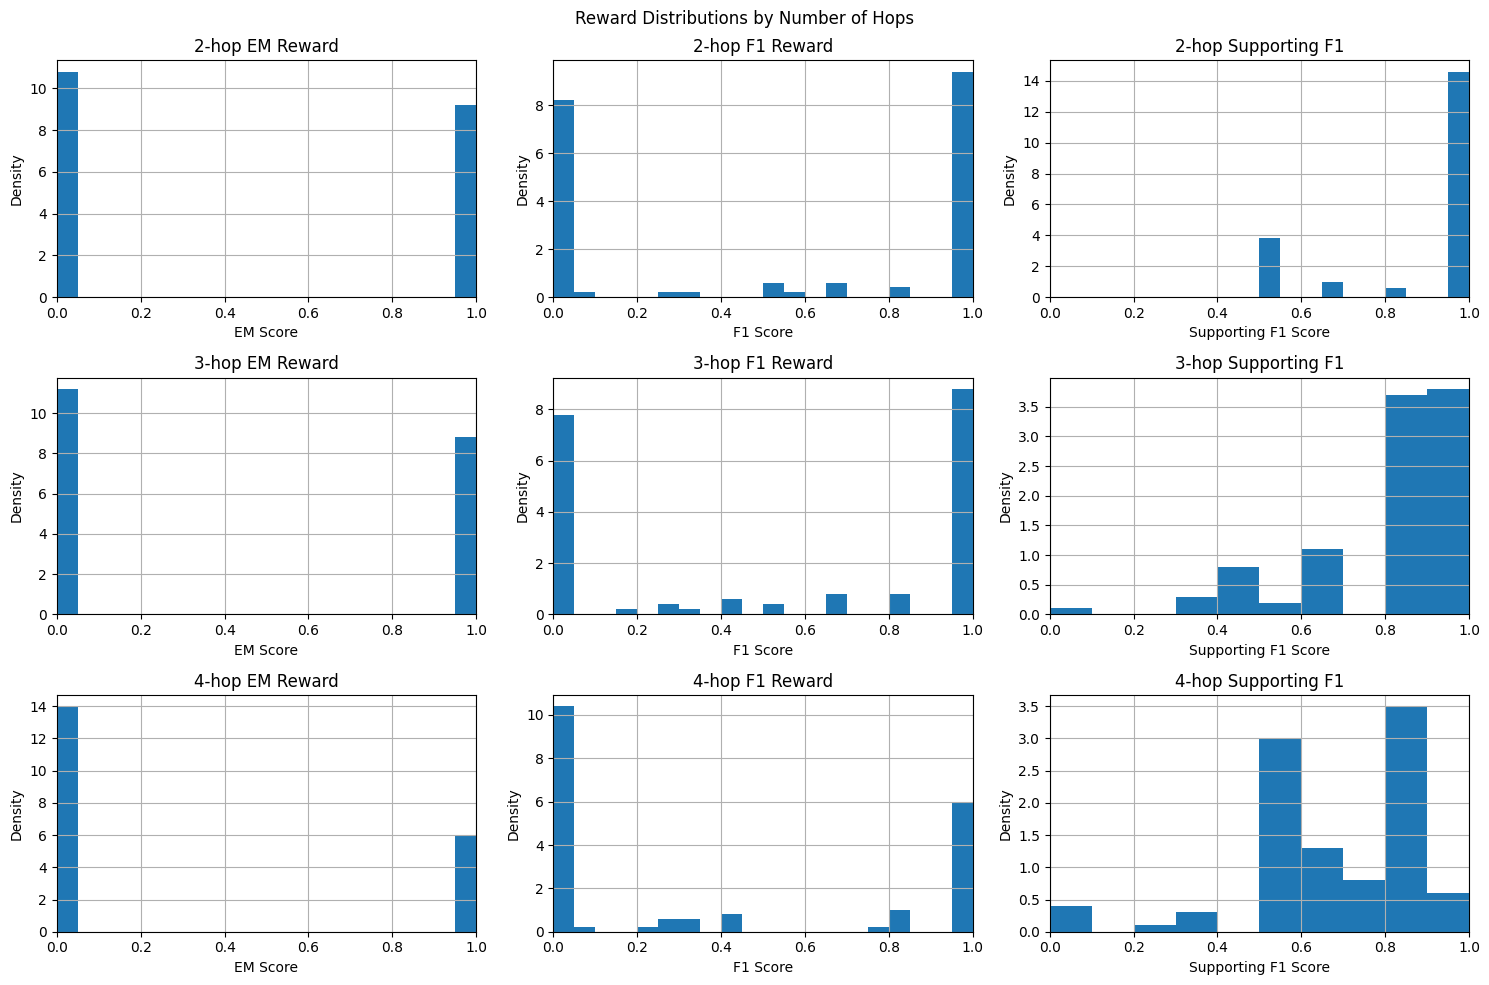

In [26]:
# Visualize rewards per n_hops
n_hops = sorted(df['n_hops'].unique())
fig, axes = plt.subplots(len(n_hops), 3, figsize=(15, 10))
fig.suptitle('Reward Distributions by Number of Hops')

for i, n_hop in enumerate(n_hops):
    subset = df[df['n_hops'] == n_hop]
    
    subset['reward.em'].hist(ax=axes[i,0], bins=20)
    axes[i,0].set_title(f'{n_hop}-hop EM Reward')
    axes[i,0].set_xlabel('EM Score')
    axes[i,0].set_ylabel('Count')
    axes[i,0].set_xlim(0, 1)
    
    subset['reward.f1'].hist(ax=axes[i,1], bins=20)
    axes[i,1].set_title(f'{n_hop}-hop F1 Reward')
    axes[i,1].set_xlabel('F1 Sggcore')
    axes[i,1].set_ylabel('Count')
    axes[i,1].set_xlim(0, 1)
    
    subset['reward.supporting_f1'].hist(ax=axes[i,2])
    axes[i,2].set_title(f'{n_hop}-hop Supporting F1')
    axes[i,2].set_xlabel('Supporting F1 Score')
    axes[i,2].set_ylabel('Count')
    axes[i,2].set_xlim(0, 1)


plt.tight_layout()


In [22]:
row = df.iloc[0]
row['prompt']

[{'content': 'Answer the question based on the information provided by tools. You have access to the following tools:\n\nretrieve: Retrieve for relevant documents by the query. The results become better if the query is more specific. It excludes documents that have already been retrieved.\n\nArguments:\n  - query: \n\nFor each step:\n1. Think through your reasoning inside <think> tags\n2. If needed, use a tool by writing a JSON command inside <tool> tags with:\n   - "name": the tool to use\n   - "args": the keyword arguments for the tool.\n3. You will see the tool\'s output inside <result> tags\n4. Continue until you can give the final answer (in a few words) inside <answer> tags.\n\nTools expect specific JSON input formats. Follow the examples carefully.\nDo not make up tools or arguments that aren\'t listed.\n\nIf the answer is not in the provided documents, try different queries with the retrieve tool.\n',
  'role': 'system'},
 {'content': 'Who is played by the director of The Good 

In [23]:
import textwrap
from IPython.display import display
import ipywidgets as widgets
from ipywidgets import HBox

def fixedwidth(text):
    if not isinstance(text, str):
        text = str(text)
    return "\n".join(textwrap.wrap(text, width=80, replace_whitespace=False))

def format_conversation(messages: list[dict]) -> str:
    return "\n".join([f"{msg['role']}: {msg['content']}" for msg in messages])

def format_row(row):
    question = row['prompt'][-1]['content']
    idx_of_question = next((i for i, msg in enumerate(row['trajectory']) if msg['role'] == 'user' and msg['content'] == question), None)
    output = []
    output.append(f"{row['id']} - {row['n_hops']} hops")
    output.append("="*80)
    output.append("Q: " + row['prompt'][-1]['content'])
    output.append("Reference Answers: " + str(row['answers']))
    output.append("Predicted Answer: " + str(row['predicted_answer']))
    output.append("")
    output.append("# Scores")
    output.append("EM: {:.3f}".format(row['reward.em']))
    output.append("F1: {:.3f}".format(row['reward.f1']))
    output.append("Supporting F1: {:.3f}".format(row['reward.supporting_f1']))
    output.append("Supporting Recall: {:.3f}".format(row['reward.supporting_recall']))
    output.append("")
    output.append("Supporting Titles: " + str(row['supporting_titles']))
    output.append("Retrieved Titles: " + str(row['retrieved_titles']))
    output.append("Missing Titles: " + str(row['missing_titles']))
    output.append("\n")
    output.append("="*80)
    output.append(format_conversation(row['trajectory'][idx_of_question:]))
    output.append("="*80)
    return "\n".join(output)

def present_row(row):
    print(format_row(row))

def create_browse_app(dataf):
    def browse_failed(i=0):
        row = dataf.iloc[i]
        present_row(row)

    index = widgets.IntText(value=0, description='Index:')
    left_button = widgets.Button(description='Previous')
    right_button = widgets.Button(description='Next')

    def on_left_button_clicked(b):
        if index.value > 0:
            index.value -= 1

    def on_right_button_clicked(b):
        if index.value < len(dataf) - 1:
            index.value += 1

    left_button.on_click(on_left_button_clicked)
    right_button.on_click(on_right_button_clicked)

    ui = HBox([left_button, index, right_button])
    out = widgets.interactive_output(browse_failed, {'i': index})

    display(ui, out)

# Create app focused on failed examples
inspect_df = df[df['reward.f1'] < 1.0].sort_values('reward.f1')
create_browse_app(inspect_df)


Output()

In [24]:
mask = (df['reward.supporting_recall'] > 0.95) & (df['reward.f1'] < 0.5)
print(len(df.loc[mask]))
create_browse_app(df.loc[mask])

42


Output()